# Pixels

![image](https://live.staticflickr.com/65535/55169807323_133b694499_b.jpg)

## Introduction

Ajga and Bajtek are observing an art exhibition. Unfortunately, they cannot see everything clearly! Nevertheless, they would like to be able to identify what is shown in the images.

## Task

You have access to a pre-trained MNIST digit classifier and a dataset of masked 28×28 images, where only **10 pixels are visible** (the rest are set to zero).

Your task is to implement the function `solution(img)`, which takes a masked image and correctly classifies the digit (0–9).

## Data

* Pre-trained CNN model (`data/mnist_classifier.pth`)
* Training set: 500 masked images with labels (`data/train.npz`)
* Validation set: 2000 masked images with labels (`data/val.npz`)

Your solution will be evaluated on a test set with the same characteristics and number of samples as the validation set. You will not have access to it during the competition.

## Evaluation Metric

Your solution will be evaluated based on **accuracy** on the hidden test set:

* if the result is **below 35%**, you will receive **0 points**,
* if the result is **above 60%**, you will receive **100 points**.

Scores between these thresholds will be scaled proportionally.

## Constraints

* The solution will be tested on the competition platform **without internet access**.
* Final evaluation must not exceed **3 minutes** (without GPU).
* Allowed libraries: `scikit-learn`, `numpy`, `pandas`, `torch`, `opencv`, `scipy`.

## Submission Files

This notebook filled with your solution (see `solution` function).

## Evaluation

During testing, the flag `FINAL_EVALUATION_MODE` will be set to `True`. The score will be computed on a hidden test set on the competition platform. If the solution does not meet the requirements or does not run correctly, it will receive **0 points**.

## Tips

1. The model was trained on full (unmasked), **normalized** MNIST images. See the `predict` function.


# Starter Code

In this section, we initialize the environment by importing the required libraries and loading the model.

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
FINAL_EVALUATION_MODE = False # During evaluation on the grader, this flag is automatically set to True.

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

import numpy as np
import torch
import torch.nn as nn
import math

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)


def load_trained_model(model_path="mnist_classifier.pth"):
    """Load a trained model."""
    model = SimpleCNN()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()
    return model


def predict(images, model):
    # normalize input!
    images = images.float()
    images = (images - 0.1307) / 0.3081
    with torch.no_grad():
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
    return preds, probs

def round_half_up(number: float) -> int:
    return int(math.floor(number + 0.5))

def compute_score(acc_val: float):
    upper_limit = 0.6
    lower_limit = 0.35
    if acc_val > upper_limit:
        return 100
    elif acc_val < lower_limit:
        return 0
    else:
        return round_half_up((acc_val - lower_limit) / (upper_limit - lower_limit) * 100)

## Data Loading

File format:

* `data/train.npz`: `images`, `labels`, `originals`
* `data/val.npz`: `images`, `labels`, `originals`

Where:

* `images` — masked images (N × 1 × 28 × 28, float16), only 10 pixels are visible, the rest are set to zero,
* `labels` — digit labels (N, int, values 0–9),


In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

model = load_trained_model("data/mnist_classifier.pth")
model.net.eval()

def load_split(path):
    d = np.load(path)
    return torch.from_numpy(d["images"]), torch.from_numpy(d["labels"]).long()

train_imgs, train_labels = load_split("data/train.npz")
val_imgs, val_labels = load_split("data/val.npz")

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}")

Train: 500, Val: 2000


## Data Inspection

Visualization of selected masked images with labels. For each example, we show the masked image (10 visible pixels) alongside the original.

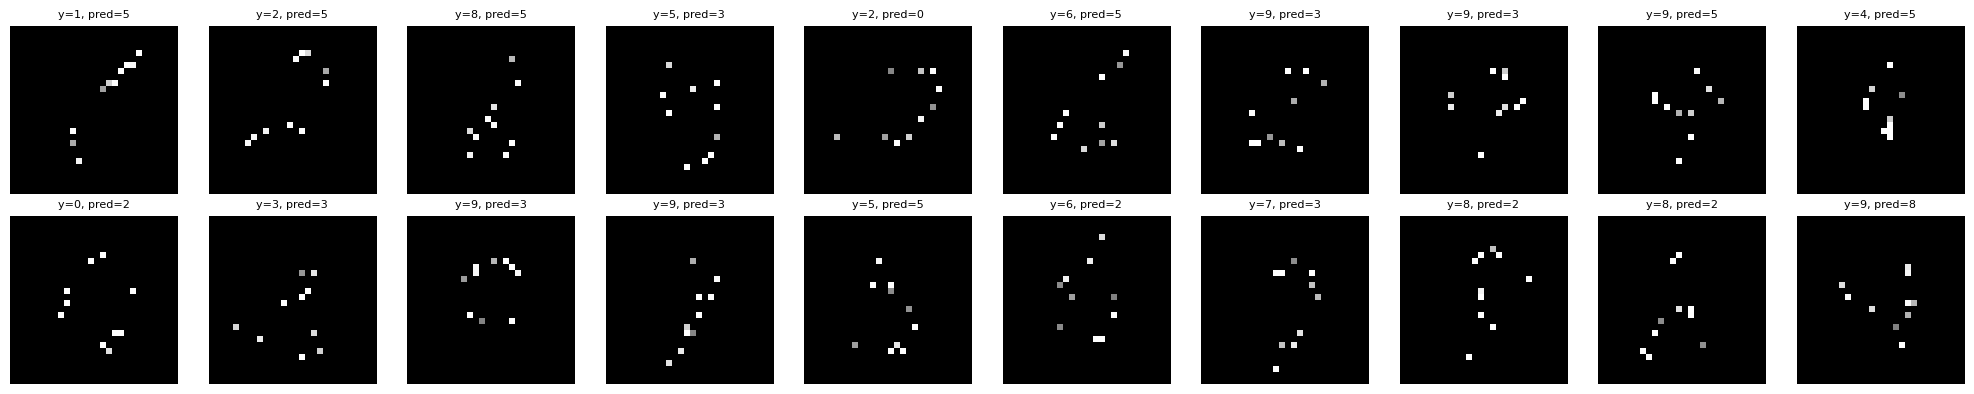

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(20):
        row = (i // 10)
        col = i % 10
        predicted = predict(train_imgs[i:i+1], model)[0].item()
        axes[row, col].imshow(train_imgs[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(f"y={train_labels[i].item()}, pred={predicted}", fontsize=8)
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

## Your Solution

In this section, place your solution. Implement the function:

* `predict(img)` — the function takes a masked image for classification. It returns the predicted label as a single number from 0 to 9.

In [ ]:
def solution(img):
    """
    Classification of masked MNIST images.

    Args:
        img: tensor (1, 28, 28) - masked image to classify

    Returns:
        predicted label (0-9) for the given image
    """
    # TODO: insert your solution here!

    # Example: direct model prediction on masked images (baseline)
    img = img.unsqueeze(0)  # add batch dimension
    predicted_label, _ = predict(img, model)
    return predicted_label.item()

## Evaluation

Running the cell below will allow you to check the accuracy of your solution on the validation set. Before submission, make sure that the entire notebook runs from start to finish without errors and without any user intervention after selecting the **"Run All"** option.

During evaluation, the model will be tested on a hidden test set.


In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    accs = []
    for img, label in zip(val_imgs, val_labels):
        pred = solution(img)
        accs.append(pred == label.item())
    acc = np.mean(accs)
    print(f"  Accuracy on the validation set: {acc*100:.2f}%")

    score = compute_score(acc)
    print(f"  Score: {score}")

  Accuracy na zbiorze walidacyjnym: 19.25%
  Liczba punktów: 0
